In [2]:

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display
import ipywidgets as widgets
import pandas as pd
import sympy as sp
import scipy.stats as stats
import sympy as sp
import jax
import jax
import jax.numpy as jnp
from jax.scipy.special import ndtr
from scipy.optimize import minimize
import os


%matplotlib ipympl




# Likelihood and Probability Difference

Probability: parameters are static,

# Likelihood for n bernoulli

### Volatility definition

Standart definition of percentage change of stock price (Return) is considered volatility.

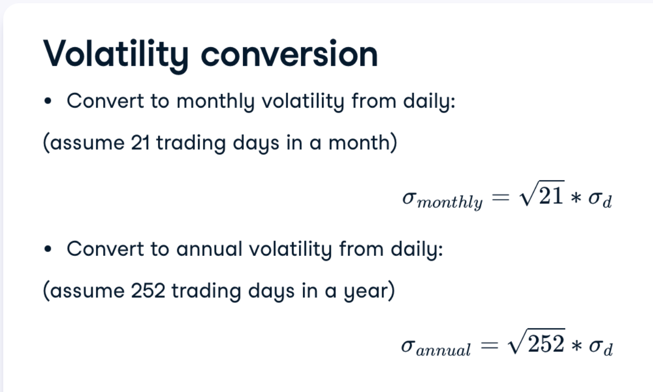


### Heteroskedasticity and Homoskedasticity
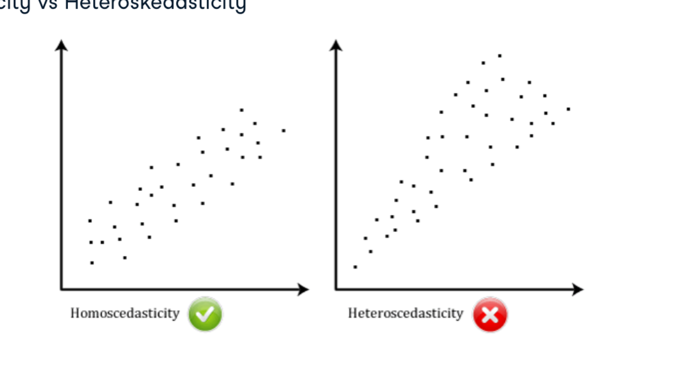


### Volatility clustering / VIX historical prices

High price changes will be followed by other high price changes
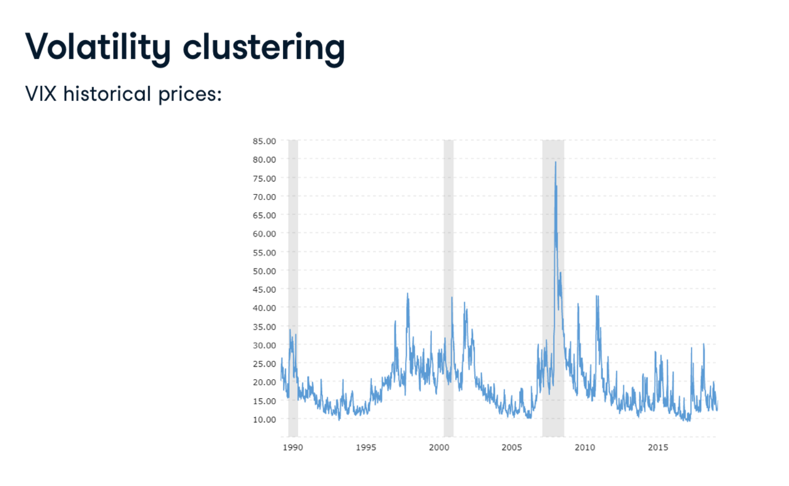
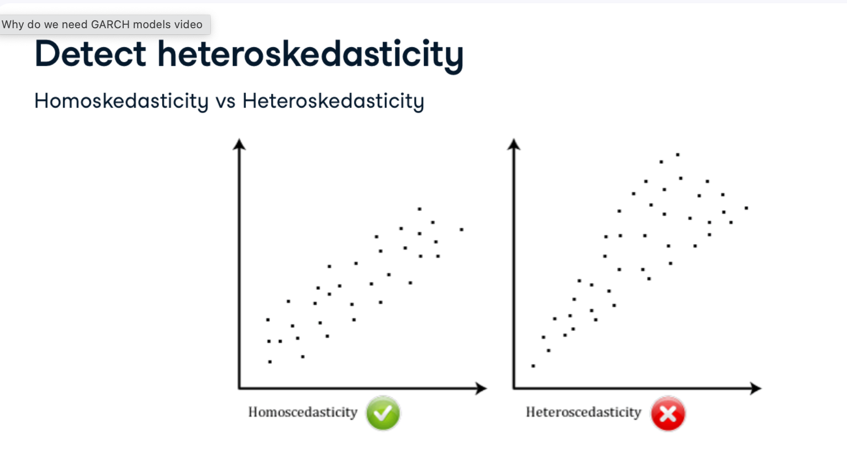

## Maximum Likelihood Estimation, OLS vs MLE

## OLS (Ordinary Least Squares)

OLS finds the parameters that minimize the sum of squared residuals:

$$\hat{\theta}_{OLS} = \arg\min_{\theta} \sum_{t=1}^{T} (y_t - \hat{y}_t)^2$$

It asks: **which parameters make my predictions as close as possible to the data?**

It has a closed-form solution:

$$\hat{\theta} = (X^TX)^{-1}X^Ty$$

**No iteration needed.** Assumes errors are i.i.d. with constant variance $\sigma^2$.

## MLE (Maximum Likelihood Estimation)

MLE finds the parameters that make the observed data most probable under an assumed distribution:

## We have used "stats.norm.fit" which does MLE and founds the parameters without needing to write the steps.


$$\hat{\theta}_{MLE} = \arg\max_{\theta} \sum_{t=1}^{T} \log f(y_t \mid \theta)$$

It asks: **which parameters would have most likely generated the data I observed?**

No closed-form solution in general — requires numerical optimization (e.g. gradient descent, Newton-Raphson).

* $\hat{\theta}$ : the parameters we are willing to estimate
    * e.g. if a normal distrubution is assumed $\theta = (\mu, \sigma)$
* $y_t$ = current value i have (return/citrus weight etc)
* $f(y_t \mid \theta)$ : probability densitiy of having this data knowing $\theta)$ is valid


## How MLE is constructed — step by step

**Step 1: Assume a distribution**

Decide where the data comes from. For returns we typically assume normal:

$$y_t \sim N(\mu, \sigma^2)$$

**Step 2: Write the likelihood of a single observation**

How probable is this observation under the assumed distribution?

$$f(y_t \mid \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(y_t - \mu)^2}{2\sigma^2}\right)$$

> The PDF $f(x_i \mid \theta)$ does not return a probability — it returns a **density**: how concentrated the distribution is at a given point. A single point has zero probability in a continuous distribution, but the PDF value tells us how likely that region is relative to others. Formally, $f(x) \cdot dx$ gives the probability of landing in a small interval around $x$. The total area under the curve integrates to 1, but individual values can exceed 1.
>
> For example, with $\mu = 155$, $\sigma = 17$: a 150g orange gives $f(150) \approx 0.0233$, while a 200g orange gives $f(200) \approx 0.0039$. **The 150g orange is about 6x more dense — meaning oranges around 150g are far more likely to appear in the sample than oranges around 200g.**  These are not probabilities, but their ratio tells us which value the distribution favors.

**Step 3: Multiply across all observations (joint likelihood)**

Since observations are i.i.d., the joint probability is a product:

$$L(\theta) = \prod_{t=1}^{T} f(y_t \mid \theta)$$

**Step 4: Take the log**

Products become sums, and numerical stability improves:

$$\ell(\theta) = \sum_{t=1}^{T} \log f(y_t \mid \theta)$$

For the normal case this expands to:

$$\ell(\mu, \sigma) = -\frac{T}{2}\log(2\pi) - T\log\sigma - \frac{1}{2\sigma^2}\sum_{t=1}^{T}(y_t - \mu)^2$$

**Step 5: Maximize**

Find the $\theta$ that makes $\ell(\theta)$ as large as possible:

$$\hat{\theta} = \arg\max_{\theta} \ \ell(\theta)$$

If a closed-form solution exists, take the derivative, set to zero, solve. Otherwise use numerical optimization.

Maximizing likelihood visualisation:
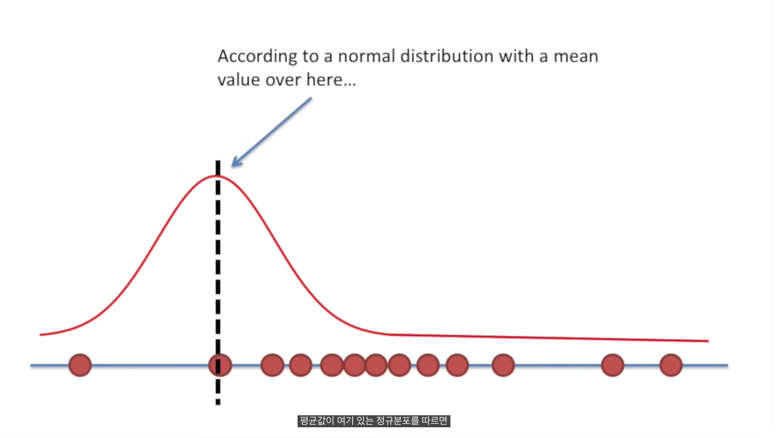
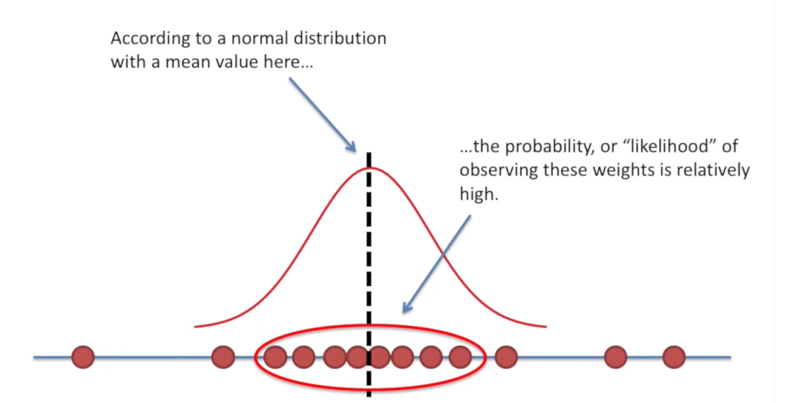

**Step 6: Closed form vs numerical**

For the normal distribution, derivatives give a closed-form solution directly:

$$\hat{\mu} = \frac{1}{T}\sum_{t=1}^{T} y_t \qquad \hat{\sigma} = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(y_t - \hat{\mu})^2}$$

For GARCH, no closed form exists — $\sigma_t^2$ depends recursively on its own past, so `scipy.optimize` is used instead.

#### What uses OLS

Linear, polynomial, Ridge, Lasso regression. Variants for relaxed assumptions: WLS (unequal variance), GLS (correlated errors), NLS (non-linear model).

#### What uses MLE

Logistic regression, GARCH, Probit/Tobit, survival models — anything where OLS assumptions break down.

#### Why GARCH uses MLE

GARCH is a **model**. MLE is the **estimation method** used to fit it.

In GARCH, $\sigma_t^2$ is recursive — it depends on its own past:

$$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

OLS assumes constant $\sigma^2$ and has no mechanism for this. MLE handles it by computing the likelihood at each $t$ using the current $\sigma_t^2$:

$$\ell(\theta) = -\frac{1}{2} \sum_{t=1}^{T} \left( \log \sigma_t^2 + \frac{\epsilon_t^2}{\sigma_t^2} \right)$$

Here $\sigma$ is no longer constant — every term in the sum uses its own $\sigma_t^2$, computed recursively from $t=1$ up to $t$. This recursive dependency is precisely why no closed-form solution exists and numerical optimization is required.

# Illustrative Maximum Likelihood Problem
Source: https://www.youtube.com/watch?v=avEd3nZWmAg&t=1413s

With citrus data, we wanna find the distrubution of orange weights.
We will take samples and increase sample weight to show


In [3]:
citrus_data = pd.read_csv('../data_nonfinancial/citrus.csv')
orange_weights = citrus_data[citrus_data['name'] == 'orange']['weight']
orange_weights.describe()

count    5000.000000
mean      152.804920
std        18.669021
min        86.760000
25%       140.147500
50%       152.665000
75%       165.430000
max       231.090000
Name: weight, dtype: float64

In [4]:
# Step 1: Assume a distrubution, for orange weights normal
# Step 2: PDF for single observation, calculate for ALL elements in sample
    # For that we will use stats.norm

# Step 3: Multiply them
# Step 4: Turn them into log
    # Log switches multiplication to addition.
         # stats norm already has a stats.norm.logpdf function

#sampling 50 items from our entire dataset
sample = np.random.choice(orange_weights, size=50, replace=False)

def total_negative_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf # for the case optimizier will return a negative
    return -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    #the sole purpose of this function is returning NEGATIVE SUM/TOTAL OF LOG DENSITY VALUES OF EACH DATA POINT.
        #why negative = scipy doesnt have maximize

# we start optimization with the mean and std of our sample
initial_params = [np.mean(sample), np.std(sample)]


result = minimize(
    total_negative_log_likelihood,
    x0=initial_params,
    args=(sample,),
    method='Nelder-Mead'
)

mu_mle, sigma_mle = result.x

# ---- Comparison: closed form ----
mu_closed = np.mean(sample)
sigma_closed = np.std(sample)

# ---- Comparison: stats.norm.fit ----
mu_fit, sigma_fit = stats.norm.fit(sample)

# ---- Results ----
print(f"MLE via scipy.optimize : mu = {mu_mle:.4f}, sigma = {sigma_mle:.4f}")
print(f"Closed form            : mu = {mu_closed:.4f}, sigma = {sigma_closed:.4f}")
print(f"stats.norm.fit         : mu = {mu_fit:.4f}, sigma = {sigma_fit:.4f}")
print(f"True population mean   : {orange_weights.mean():.4f}")
print(f"Log-likelihood         : {-result.fun:.4f}")



MLE via scipy.optimize : mu = 155.5520, sigma = 20.0088
Closed form            : mu = 155.5520, sigma = 20.0088
stats.norm.fit         : mu = 155.5520, sigma = 20.0088
True population mean   : 152.8049
Log-likelihood         : -220.7555


## Closed form and result from numerical analysis
The numerical MLE and the closed-form solution produce identical results because for the normal distribution, the closed-form solution **is** the MLE — it is simply derived analytically rather than numerically.

Taking the derivative of the log-likelihood with respect to $\mu$ and setting it to zero:

$$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n}(x_i - \mu) = 0 \implies \hat{\mu} = \frac{1}{n}\sum x_i$$

And with respect to $\sigma$:

$$\frac{\partial \ell}{\partial \sigma} = -\frac{n}{\sigma} + \frac{1}{\sigma^3}\sum_{i=1}^{n}(x_i - \mu)^2 = 0 \implies \hat{\sigma} = \sqrt{\frac{1}{n}\sum(x_i - \hat{\mu})^2}$$

`scipy.optimize` arrives at the same values by searching numerically. Both solve the same problem — one analytically, one iteratively.

#### In GARCH, taking these derivatives is not tractable due to the recursive structure of $\sigma_t^2$, which is why numerical optimization is the only option.

## Value of Log-Likelihood

The log-likelihood value answers: **how well do these parameters explain the observed data?**

It is not meaningful in isolation — it is used to compare models against each other.

$$\ell(\hat{\theta}) = \sum_{i=1}^{n} \log f(x_i \mid \hat{\theta})$$

A higher (less negative) value means the estimated parameters would have generated the observed data with higher probability. For example:

- $\mu=155, \sigma=17$ → $\ell = -200$
- $\mu=200, \sigma=5$ → $\ell = -500$

The first model fits the data far better.

**Why is it negative?**

Because $\log f(x_i) < 0$ whenever $f(x_i) < 1$, which is almost always the case for PDF values. Summing $n$ negative numbers gives a large negative value.

**What is it used for?**

- Comparing models: GARCH(1,1) vs GARCH(1,2)
- Computing AIC / BIC: log-likelihood penalized by number of parameters
- Likelihood ratio test: is adding a parameter statistically justified?

---

**Why `result.fun`?**

`scipy.optimize.minimize` returns a result object with several fields:

```python
result.x      # optimal parameters [mu, sigma]
result.fun    # final value of the function being minimized
result.success  # did the optimizer converge?
```

We minimized the **negative** log-likelihood, so `result.fun` holds the minimum negative log-likelihood. To get the actual log-likelihood back:

```python
log_likelihood = -result.fun
```